In [1]:
#IMPORTS NECESARIOS

#Pandas para gestionar los dataframes
import pandas as pd

#Numpy para manejar los arrays más eficientemente
import numpy as np

#Tensorflow para varias funcionalidades
import tensorflow as tf

#Keras para varias funcionalidades de la red clásica
import keras

#Imports de Scikit-learn
#Train_test_split apra separar los conjuntos de train,validacion y test
from sklearn.model_selection import train_test_split
#Dos scalers: StandardScaler y MinMaxScaler para estandarizar o normalizar los datos
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import MinMaxScaler

#Imports para las funciones de coste o loss de la red
from keras.losses import MeanSquaredError
from tensorflow.keras.metrics import MeanAbsoluteError


#Matplotly para msotrar gráficas
import matplotlib.pyplot as plt

#Import de las capas LTSM y Dense de la red clásica.
from keras.layers import LSTM, Dense

#Import de Sequential para la red clásica
from keras.models import Sequential

#Optimziador de la red clásica
from keras.optimizers import Adam

#Joblib para guardar los resultados
import joblib

In [2]:
#Clase que conforma la LTSM clásica
class LSTMHyperModel():
    #Constructor de la clase. Recibe el tamaño de entrada y de salida de la red como parámetro
    def __init__(self, input_shape, output_units):
        self.input_shape = input_shape
        self.output_units = output_units

    #Funcion para construir la red
    def build(self):
        model = Sequential()

        #Capa LTSM. Se puede modificar:
            #units: nuemro de neuronas en esta capa
            #activation: función de activación, por defecto RELU
            #dropout: modificar entre 0.0 y 0.3 para evitar el sobreajuste. Valores mayores pueden hacer que la red desaprenda demasiado
        model.add(LSTM(
            units=32,
            activation='relu',  # Se puede probar también tanh
            dropout=0.1,
            input_shape=self.input_shape, #Tamaño de la capa de entrada
            return_sequences=True #Este valor es importante para que devuelva la secuencia de horas
        ))
        
        #AQUÍ SE MUESTRA COMO SERIA AÑADIR OTRA CAPA ADICIONAL, también se puede modificar los parámetros anteriores
        # model.add(Bidirectional(LSTM(
        #    units=32,
        #    activation='relu',  # Using tanh for cuDNN optimization
        #    dropout=0.2,
        #    #recurrent_dropout=hp.Float('recurrent_dropout2', min_value=0.1, max_value=0.5, step=0.1),
        #    return_sequences=True
        # )))

        #Capa Dense final de la red
        model.add(Dense(self.output_units))

        #Compilamos la red. Se puede probar con otros optimizadores que nos ean Adam y otros valores de learning rate. Así como otra métrica de loss que no sea mse
        model.compile(optimizer=Adam(learning_rate=0.0001), loss='mse', metrics=['mae'])

        #Devolvemos la red resultante
        return model

In [5]:
#Función para preparar los datos. Se puede modificar para ajustarla a otros conjuntos de datos.
#Recibe como parámetros:
    #df: dataframe con los datos de la serie temporal
    #wz: ventana de tiempo pasasdo
    #forecast: ventana de tiempo futura a predecir
    #lista_gases: Lista de gases que vamos a predecir
def prepare_station_data(df, wz, forecast, lista_gases):
    
    #Convertimos la columna timestamp a valor de tiempo Datetime en caso de que no lo estuviese ya
    df['timestamp'] = pd.to_datetime(df['timestamp'])
    
    # Extracción de características del timestamp:
    df['hour']=df['timestamp'].dt.hour
    df['day']=df['timestamp'].dt.day
    df['month']=df['timestamp'].dt.month
    df['year']=df['timestamp'].dt.year  
    df['day_of_week']=df['timestamp'].dt.dayofweek
    df['holiday']=0
    df['holiday']=df['holiday'].mask(df['day_of_week'].isin([5,6]),1)
    # Festivos nacionales: Navidad y Año Nuevo:
    christmas=(df['month']==12) & (df['day']==25)
    new_year_day=(df['month']==1) & (df['day']==1)
    for condition in [christmas,new_year_day]:
        df['holiday']=df['holiday'].mask(condition,1)
    #Se pueden añadir más fechas festivas

    #Definimos 'timestamp' como indice para reordenar los datos
    df.set_index('timestamp', inplace=True)
    # Si quieres resetear el índice después del resampling (opcional)
    df.reset_index(inplace=True)
    
    #Eliminamos el timestamp
    df.drop('timestamp',inplace=True, axis=1)

    #Mostramos el estado del dataset antes de convertirlo en los conjunto de train, test y validacion
    print(df)

    #Preparamos las features y las variables objetivo
    #Las features incluyen a priori todos los valores ya que necesitmaos construir las ventanas anteriores de tiempo. Despues se eliminan los gases
    X = df.copy()
    #Las variables objetivo son los gases
    y = df[lista_gases]

    #Las ventanas de tiempo
    WINDOW_SIZE = wz  # Ventana de 24 horas, con 4 medidas por hora. 
    FORECAST_HORIZON = forecast  # Predecir las próximas 24 horas, también con 4 medidas por hora. 

    #Definimos un Scaler para escalar o normalizar los datos. En este caso utilizamos MinMax pero se puede probar tambien StandarScaler
    scaler_X = MinMaxScaler(feature_range=(0, 1))
    #scaler_X=StandardScaler()

    #Escalamos o normalizamos los datos
    X_scaled = pd.DataFrame(scaler_X.fit_transform(X), columns=X.columns)
    
    #Lo mismo que lo anterior pero para las variables objetivo
    scaler_y = MinMaxScaler(feature_range=(0, 1))
    #scaler_y=StandardScaler()
    y_scaled = pd.DataFrame(scaler_y.fit_transform(y), columns=y.columns)

    #Función para crear ventanas de tiempo (lagged features en ventanas de tiempo)
    def create_lagged_features(features, targets, window_size, forecast_horizon):
        X, y = [], []
        for i in range(len(features) - window_size-forecast_horizon + 1):
            X.append(features.iloc[i:i+window_size].values)  # Ventana de entrada de características
            y.append(targets.iloc[i+window_size:i+window_size+forecast_horizon].values)  # Etiquetas para el horizonte de predicción
        return np.array(X), np.array(y)
    #Obtenemos las ventanas pasadas en X y las futuras en y
    X_lagged, y_lagged = create_lagged_features(X_scaled, y_scaled, WINDOW_SIZE, FORECAST_HORIZON)
    
    #Comprobamos que las dimensiones de las ventas son correctas
    print("Shape of X_lagged:", X_lagged.shape)  # Debería mostrar (n_samples, 24, num_features)
    
    #Devolvemos las ventanas de tiempo pasadas y futuras así como los scaler para desnormalizar los datos a futuro
    return X_lagged, y_lagged, scaler_X, scaler_y 

In [6]:
#Función apra entrenar la red clásica
#Sus parámetros on:
    #csv_name: dirección donde se encuentra el csv con los datos
    #wins: tamaño de la ventana pasada
    #fore: tamaño de la ventana a predecir
def train(csv_name,wins,fore):
    # Leemos el dataset
    df = pd.read_csv(csv_name)

    #Definimos el tamaño de las ventanas en función de los parámetros. Se puede modificar esto apra ser más eficiente
    ventana = wins
    forecast = fore
    
    # Preparar los datos de la estación. Llamamos a la función previa con la lista de gases que nos interese. Os dejo por defecto el ozono pero podeis probar con todos
    #['SO2', 'CO', 'NO', 'NO2', 'PM10', 'NOX', 'O3']
    gases_predecir=['O3']
    X_lagged, y_lagged, scaler_X, scaler_y = prepare_station_data(df, ventana, forecast, gases_predecir)
    

    # SEPARACIÓN DE LOS DATOS EN CONJUNTOS DE ENTRENAMIENTO, VALIDACIÓN Y PRUEBA
    # Tamaño del conjunto de datos
    total_samples = X_lagged.shape[0]
    # Definir los tamaños de los conjuntos de datos
    train_size = int(0.7 * len(X_lagged))  # 70% para entrenamiento
    val_size = int(0.10 * len(X_lagged))  # 10% para validación
    test_size = len(X_lagged) - train_size - val_size  # 20% para prueba
    # Dividir los datos en entrenamiento, validación y prueba
    X_train, X_val, X_test = X_lagged[:train_size], X_lagged[train_size:train_size+val_size], X_lagged[-test_size:]
    y_train, y_val, y_test = y_lagged[:train_size], y_lagged[train_size:train_size+val_size], y_lagged[-test_size:]

    #Comprobamos que las dimensiones resultantes sean correctas. Deberia ser (tamaño_train,24,numero_gases)
    print("Shape de Train:",X_train.shape)
    
    # Dimensiones de entrada y salida de la red clásica
    input_shape = (X_train.shape[1], X_train.shape[2])
    output_units = y_train.shape[2] # Ajustar según tus etiquetas

    #Construimos la red con la clase definida previamente
    model= LSTMHyperModel(input_shape=input_shape, output_units=output_units).build()

    #Condición de early stopping para evitar perder tiempo si la red no aprende y para evitar posibles sobreajustes. Modificar "patience" para definiar cuantas epocas espera a tener mejoras
    early_stopping = keras.callbacks.EarlyStopping(patience=10, restore_best_weights=True)

    #Llamamos a la función fit para entrenar la red. Modificar:
        #epochs: Para definir el numero máximo de epocas que entrenará la red (en caso de no tener early stopping o que la red siga mejorando)
        #batch_size: Tamaño de datos de entrenamioento que va utilizando el modelo en el entrenamiento. Cuando mayor más rápido pero aprende peor. Si es muy pequeño puede cambiar con demasiada frecuencia los parámetros que va aprendiendo la red
    model.fit(X_train, y_train, validation_data=(X_val, y_val), epochs=20, batch_size=32,callbacks = [early_stopping])


    #Podemos hacer un summary de la red resultante
    #model.summary()

    #Calculamos el loss sobre Test para hacernos una idea del rendimiento de la red
    test_loss = model.evaluate(X_test, y_test)
    print("Test MSE:", test_loss)
    
    #Guardamos el modelo el modelo
    model.save('./Modelo_LTSM_clasico.keras')
    
    # Guardar Scalers para poder desescalar los datos posteriormente 
    #Se pueden cargar estos SCALERS en el futuro así: scaler_X = joblib.load('scaler_X.pkl') scaler_Y = joblib.load('scaler_Y.pkl')
    joblib.dump(scaler_X, 'scaler_X_pru.pkl') 
    joblib.dump(scaler_y, 'scaler_Y_pru.pkl') 

    #Devolvemos la red entrenada, los Scalers y el conjunto de test para hacer pruebas y comparativas más adelante
    return model,scaler_X,scaler_y,X_test,y_test

In [7]:
#Esta celda es para echarle un vistazo al dataframe original
df = pd.read_csv("STASA13_AEMET.csv")
df

,SO2,CO,NO,NO2,PM10,NOX,O3,"PM2,5",SH2,vmax,...,hr,ts,pres_nmar,tamin,ta,tamax,tpr,inso,tss5cm,timestamp
0,5.03750,0.35500,26.16750,29.07500,15.22500,69.89750,1.88750,8.615000,4.408750,3.2,...,92.0,5.8,1030.3,4.1,4.2,4.5,3.0,0.0,8.5,2022-01-01 00:00:00
1,4.92000,0.32250,22.78250,28.19500,15.21750,63.73750,1.71500,9.155000,4.058750,3.4,...,92.0,5.9,1030.1,4.0,4.2,4.2,3.0,0.0,8.3,2022-01-01 01:00:00
2,4.78000,0.27500,12.12750,25.71750,8.21000,44.63750,1.92750,9.120000,3.216250,4.9,...,92.0,5.8,1030.1,4.0,4.1,4.4,2.9,0.0,8.2,2022-01-01 02:00:00
3,4.84500,0.24250,7.15000,24.37250,3.72250,35.52750,2.17500,8.035000,3.253750,3.6,...,92.0,5.0,1030.3,3.1,3.1,4.1,1.9,0.0,8.0,2022-01-01 03:00:00
4,4.60500,0.23000,6.54000,19.98500,1.36250,30.18500,2.43250,7.527500,2.977500,2.9,...,92.0,4.6,1030.5,3.0,3.1,3.2,1.9,0.0,7.9,2022-01-01 04:00:00
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
23851,1.57750,0.25875,4.83000,19.54750,22.27500,27.16250,55.91875,7.645833,11.690000,3.0,...,87.0,20.1,1015.5,18.2,18.4,18.4,16.2,0.0,23.7,2024-09-20 19:00:00
23852,1.59625,0.27500,4.32125,16.10000,17.94250,22.13000,48.27625,7.530833,2.508125,2.5,...,89.0,19.7,1015.7,18.2,18.4,18.4,16.6,0.0,23.1,2024-09-20 20:00:00
23853,1.46750,0.22750,3.61750,14.61875,15.27250,20.41000,51.51000,7.411667,3.917500,3.1,...,88.0,19.8,1015.8,18.4,18.4,18.5,16.4,0.0,22.7,2024-09-20 21:00:00
23854,1.49500,0.24125,2.22500,10.14000,16.28875,13.48000,56.50500,7.259167,3.337500,5.0,...,93.0,19.3,1015.9,17.7,17.7,18.5,16.6,0.0,22.4,2024-09-20 22:00:00


In [8]:
nom='STASA13_AEMET.csv'
modelo,scaler_X,scaler_y,X_test,y_test=train(nom,24,24)

           SO2       CO        NO       NO2      PM10       NOX        O3  \
0      5.03750  0.35500  26.16750  29.07500  15.22500  69.89750   1.88750   
1      4.92000  0.32250  22.78250  28.19500  15.21750  63.73750   1.71500   
2      4.78000  0.27500  12.12750  25.71750   8.21000  44.63750   1.92750   
3      4.84500  0.24250   7.15000  24.37250   3.72250  35.52750   2.17500   
4      4.60500  0.23000   6.54000  19.98500   1.36250  30.18500   2.43250   
...        ...      ...       ...       ...       ...       ...       ...   
23851  1.57750  0.25875   4.83000  19.54750  22.27500  27.16250  55.91875   
23852  1.59625  0.27500   4.32125  16.10000  17.94250  22.13000  48.27625   
23853  1.46750  0.22750   3.61750  14.61875  15.27250  20.41000  51.51000   
23854  1.49500  0.24125   2.22500  10.14000  16.28875  13.48000  56.50500   
23855  1.47750  0.24625   1.89375   8.56125  16.81375  11.46125  52.84250   

          PM2,5        SH2  vmax  ...  tamax   tpr  inso  tss5cm  hour  day

C:\Users\guill\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/20
521/521 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - loss: 0.0025 - mae: 0.0379 - val_loss: 8.5523e-04 - val_mae: 0.0230
Epoch 2/20
521/521 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 9.6614e-04 - mae: 0.0241 - val_loss: 7.1678e-04 - val_mae: 0.0218
Epoch 3/20
521/521 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 7.3349e-04 - mae: 0.0209 - val_loss: 5.9971e-04 - val_mae: 0.0199
Epoch 4/20
521/521 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 6.3079e-04 - mae: 0.0193 - val_loss: 5.9445e-04 - val_mae: 0.0198
Epoch 5/20
521/521 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 5.7769e-04 - mae: 0.0185 - val_loss: 5.9119e-04 - val_mae: 0.0196
Epoch 6/20
521/521 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 5.4268e-04 - mae: 0.0179 - val_loss: 5.7902e-04 - val_mae: 0.0193
Epoch 7/20
521/521 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 5.2182e-04 - mae: 0.0175 - val_loss: 5.6059e-04 - val_mae: 0.0191
Epoch 8/20
521/521 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 5.0337e-04 - mae: 0.0171 - val_loss: 5.6456e-04 - val_mae: 0.0

In [9]:
modelo.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 24, 32)         │         7,936 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 24, 1)          │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 23,909 (93.40 KB)

 Trainable params: 7,969 (31.13 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 15,940 (62.27 KB)

In [10]:
#Función para predecir los gases a 24 horas y ver qué tal se ajusta.
#Recibe:
    #X_test: Conjunto de test con las features
    #y_test: Conjunto de test con los gases a predecir
    #ven: tamaño de la ventana pasada (horas)
    #fore: tamaño de la ventana predecir (horas)
    #modelo: la red ya entrenada
    #scaler_X: objeto Scaler para normalizar o desnormalizar los datos sobre las features
    #scaler_Y: objeto Scaler para normalizar o desnormalizar los datos sobre las variables objetivo (gases)
def predict(X_test,y_test,ven,fore,modelo,scaler_X,scaler_Y):
    #Definimos el tamaño de las ventanas de tiempo pasada y futura en funcion de los parametros
    ventana = ven
    forecast = fore
    #Definimos el modelo en funcion del parámetro recibido
    model = modelo

    #Definimos las features del dato a predecir. En este caso las últimas 24 horas. Es decir, el último elemento de test en features (X)
    entrada=X_test[-1].reshape(1,24,X_test.shape[2])

    #Tomamos la ventana previa al ultimo dato para tener el historico
    historico=y_test[-24]

    #Lo mismo con los gases. Toammos el último elemento (ultima ventana de 24 horas)
    reales = y_test[-1]

    #Hacemos la predicción sobre el último tramo de 24 horas
    prediccion = model.predict(entrada)[0]

    #ESTOS PASOS SON NECESARIOS PARA MOSTRAR EL RESULTADO EN GRAFICAS DESPUES (Esta parte si teneis dudas la podemos comentar en detalle)
    #Aplanamos los datos para podeer desnormalizarlos
    entrada_flattened = entrada.reshape(-1, X_test.shape[2])
    #Desnormalizamos los datos utilizando el Scaler correspondiente
    entrada_descaled = scaler_X.inverse_transform(entrada_flattened)
    
    #Hacemos la transpuesta del resultado para quedarnos con las ventanas de 24 horas de cada gas. Esto es necesario porque sino tendríamos 24 conjuntos de todos los gases.
    historico = np.transpose(historico[:, :y_test.shape[2]])  # Seleccionar solo los gases y transponer

    #Desnormalziamos los valroes predichos por el modelo par poder compararlos con los reales
    #prediccion = scaler_Y.inverse_transform(prediccion)  # Desescalar las predicciones
    prediccion = np.transpose(prediccion)  # Transponer las predicciones para graficar

    #Desnormalizamos los datos originales de test.
    #reales = scaler_Y.inverse_transform(salida)  # Desescalar los valores reales
    reales = np.transpose(reales)  # Transponer los valores reales para graficar


    #Coisntruimos los arrays que queremos mostrar
    tiempoHistorico = np.arange(historico.shape[1])
    tiempoPredicción = np.arange(historico.shape[1],historico.shape[1] + prediccion.shape[1])
    plt.figure(figsize=(20, 10))

    # Graficar cada fila de la matriz
    for i in range(prediccion.shape[0]):
        plt.figure(figsize=(20, 10))
        # Graficar los datos históricos
        plt.plot(tiempoHistorico, historico[i, :], label=f'Gas {i+1} - Histórico', linestyle='-', color='blue')
        # Graficar las predicciones
        plt.plot(tiempoPredicción, prediccion[i, :], label=f'Gas {i+1} Predicción', linestyle='--', color='red')

        # Graficar los datos reales
        plt.plot(tiempoPredicción, reales[i, :], label='Reales', linestyle='-', color='green')

        # Añadir etiquetas y título
        plt.xlabel('Tiempo')
        plt.ylabel('Cantidad de Gas')
        plt.title('Evolución Temporal de la Cantidad de Gas')
        plt.legend()  # Mostrar leyenda para identificar cada gas
        plt.grid(True)  # Añadir una rejilla para mejorar la lectura del gráfico
        plt.draw()
        #print ("Presiona espacio para continuar...")
        #plt.waitforbuttonpress()
        plt.show()
    #desactivando la interactividad
    plt.ioff
    print ('Visualizados todos los gases')  

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 132ms/step


<Figure size 2000x1000 with 0 Axes>

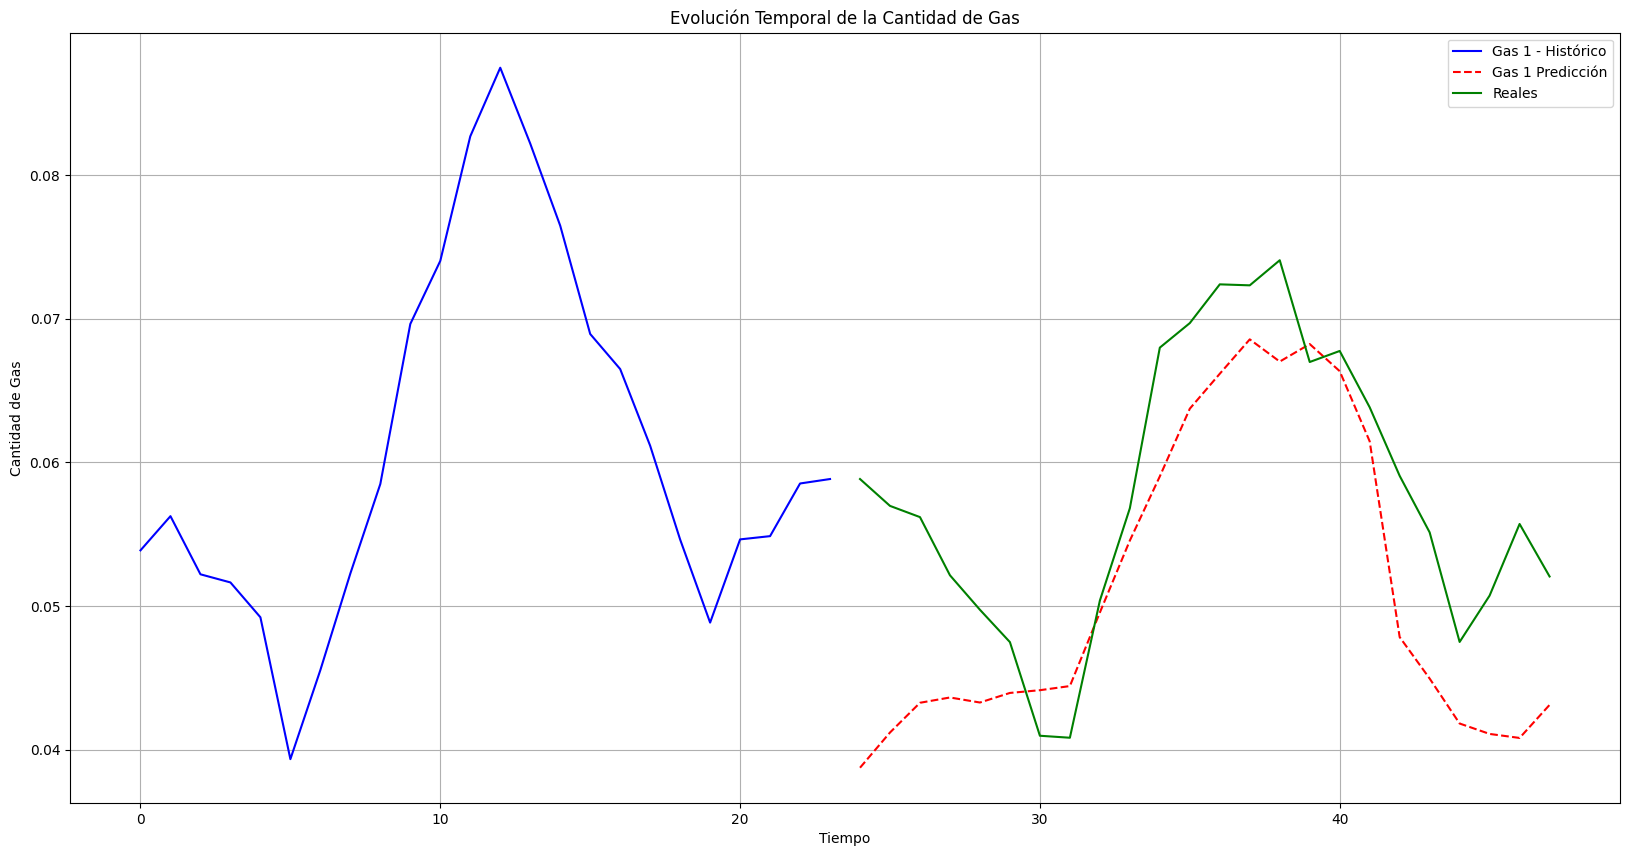

Visualizados todos los gases


In [11]:
predict(X_test,y_test,24,24,modelo,scaler_X,scaler_y)      

149/149 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
O3


<Figure size 2000x1000 with 0 Axes>

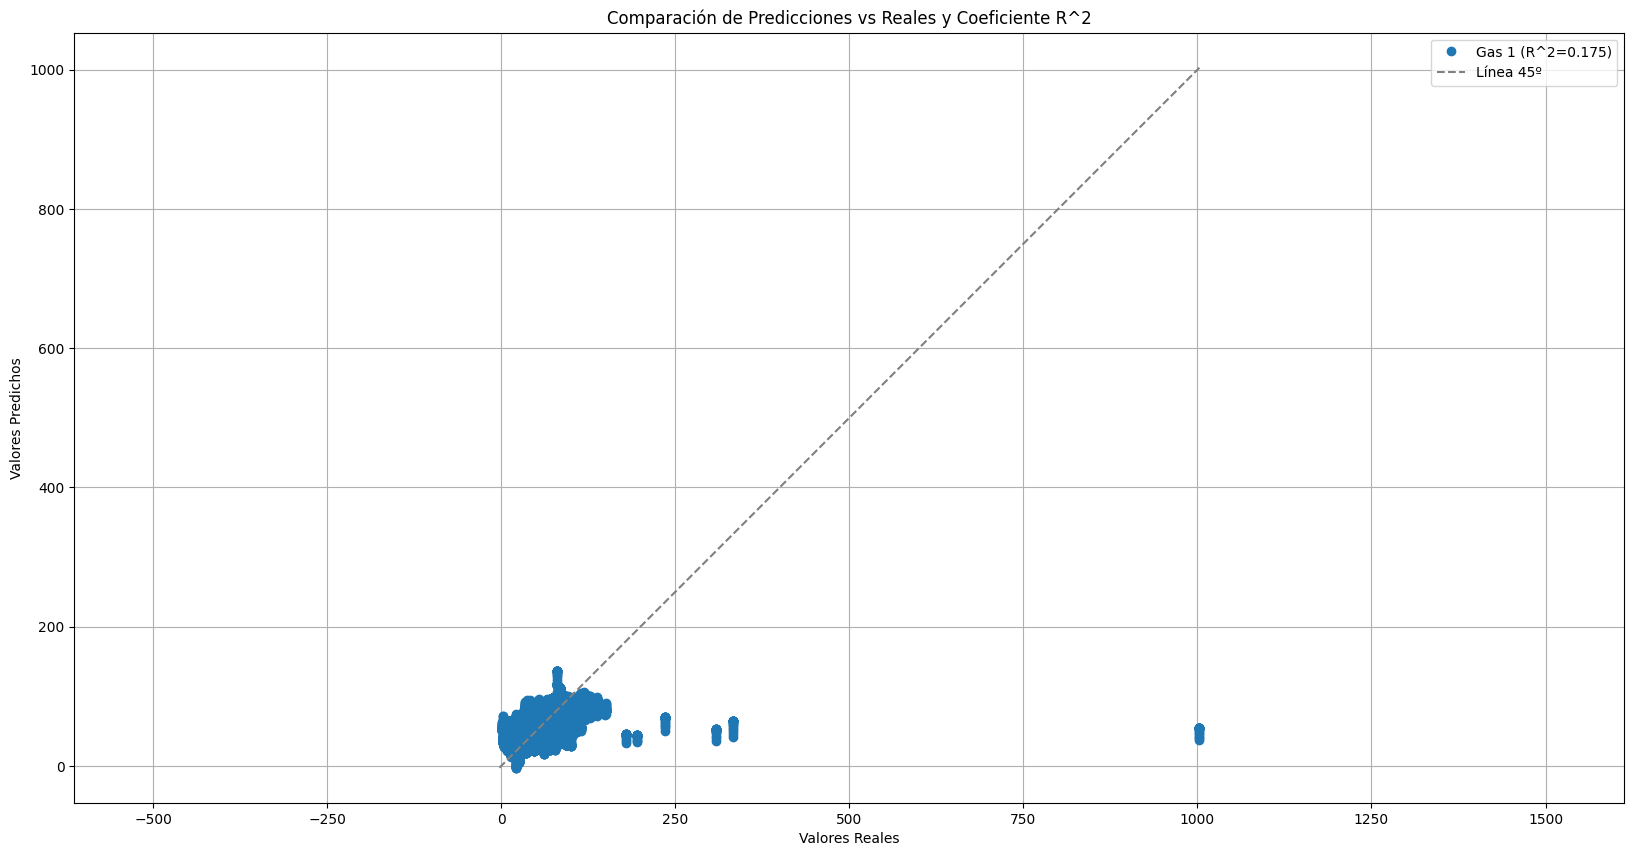

Gas 1: R^2 = 0.175


In [12]:
from sklearn.metrics import r2_score
#Version provisional de analisis sobre el conjunto de test. Pendiente de debugear
def predict_full_test(X_test, y_test, ven, fore, modelo, scaler_X, scaler_Y):

    lista_gases=['O3']
    
    # Predicciones de todo el conjunto de test de una vez
    X_test_scaled = X_test.reshape(X_test.shape[0], 24, X_test.shape[2])  # Asegurarse de la forma correcta
    y_test_scaled = y_test  # Supongo que ya están escalados

    # Realizar predicciones para todo el conjunto de prueba
    predicciones = modelo.predict(X_test_scaled)

    # Desescalar las predicciones y los valores reales
    num_variables = y_test.shape[2]  # Número de variables (gases)

    # Desescalar predicciones
    predicciones_descaled = []
    for i in range(predicciones.shape[0]):  # Desescalar cada ventana de predicción
        prediccion_descaled = scaler_Y.inverse_transform(predicciones[i])
        predicciones_descaled.append(prediccion_descaled)
    predicciones_descaled = np.array(predicciones_descaled)

    # Desescalar valores reales
    reales_descaled = []
    for i in range(y_test_scaled.shape[0]):
        real_descaled = scaler_Y.inverse_transform(y_test_scaled[i])
        reales_descaled.append(real_descaled)
    reales_descaled = np.array(reales_descaled)

    # Transponer para tener (número de gases, tiempo)
    predicciones_totales = np.transpose(predicciones_descaled, (2, 0, 1)).reshape(num_variables, -1)
    reales_totales = np.transpose(reales_descaled, (2, 0, 1)).reshape(num_variables, -1)

    # Graficar R^2 para cada variable (gas)
    r2_scores = []
    plt.figure(figsize=(20, 10))
    for i in range(num_variables):
        plt.figure(figsize=(20, 10))
        print(lista_gases[i])
        r2 = r2_score(reales_totales[i], predicciones_totales[i])
        r2_scores.append(r2)

        # Gráfico del R^2 de cada gas/variable
        plt.plot(reales_totales[i], predicciones_totales[i], 'o', label=f'Gas {i+1} (R^2={r2:.3f})')
        
        # Dibujar la línea de 45 grados (predicciones perfectas)
        min_val = min(reales_totales[i].min(), predicciones_totales[i].min())
        max_val = max(reales_totales[i].max(), predicciones_totales[i].max())
        plt.plot([min_val, max_val], [min_val, max_val], '--', color='gray', label='Línea 45º')

        # Asegurarse de que ambos ejes estén en la misma escala
        plt.axis('equal')
    
        plt.xlabel('Valores Reales')
        plt.ylabel('Valores Predichos')
        plt.title('Comparación de Predicciones vs Reales y Coeficiente R^2')
        plt.legend()
        plt.grid(True)
        plt.show()

    # Mostrar los resultados R^2
    for i, r2 in enumerate(r2_scores):
        print(f"Gas {i+1}: R^2 = {r2:.3f}")

predict_full_test(X_test, y_test, 24, 24, modelo, scaler_X, scaler_y)